In [1]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA
from collections import defaultdict
import math

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "num_seeds": 3,  # Number of repeated trials for error bars
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 2) Vector/Feature-Space Distance Functions
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))

def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)

def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))

def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)

DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),  # example p=3
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}

###############################################################################
# 3) EmbeddingTracker for Mahalanobis or the simpler distances
###############################################################################
class EmbeddingTracker:
    """
    A tracker that maintains:
    - An exponential-moving-average (EMA) of the embedding mean
    - An exponential-moving-average covariance (for Mahalanobis)
    - A selected distance metric: from one of the DISTANCE_FUNCTIONS
    """
    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name

        # For all trackers, keep track of the mean.
        self.mean = np.zeros((embedding_dim,))
        self.count = 0

        # Mahalanobis-specific
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        """Update the running mean (and covariance, if Mahalanobis)."""
        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding

            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(diff, diff)
        self.count += 1

    def compute_distance(self, embedding):
        """Compute distance between 'embedding' and the tracker's current mean."""
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            cov_inv = np.linalg.pinv(self.cov)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)

###############################################################################
# 4) Single-Seed Data Collection
###############################################################################
def collect_data_single_seed(seed):
    """Run the entire process once for a given seed."""
    set_seed(seed)

    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            key = (dataset_name, model_name)

            # We'll try multiple distances, including Mahalanobis
            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    # print(f"[Seed={seed}] Distance={distance_name}, drift_strength={drift_strength} ...")
                    drifted_texts = introduce_gradual_drift(drift_texts, fraction_shuffle=drift_strength)
                    test_texts = baseline_texts + drifted_texts

                    # 1) No PCA
                    embedding_dim_no_pca = baseline_embs.shape[1]
                    tracker_no_pca = EmbeddingTracker(
                        embedding_dim_no_pca,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    distance_scores_no_pca = []
                    time_overhead_no_pca = []

                    # Initialize tracker with baseline distribution
                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        tracker_no_pca.update(mean_emb)

                    # Process the combined test set (baseline + drifted)
                    start_time_no_pca = time.time()
                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        overhead_start = time.time()
                        dist = tracker_no_pca.compute_distance(mean_emb)
                        overhead_end = time.time()
                        distance_scores_no_pca.append(dist)
                        time_overhead_no_pca.append(overhead_end - overhead_start)
                        tracker_no_pca.update(mean_emb)
                    end_time_no_pca = time.time()

                    final_dist_no_pca = distance_scores_no_pca[-1] if distance_scores_no_pca else 0.0
                    time_no_pca = end_time_no_pca - start_time_no_pca
                    avg_overhead_no_pca = np.mean(time_overhead_no_pca)

                    # 2) With PCA
                    embedding_dim_pca = args["pca_components"]
                    tracker_pca = EmbeddingTracker(
                        embedding_dim_pca,
                        alpha=0.01,
                        distance_name=distance_name
                    )
                    distance_scores_pca = []
                    time_overhead_pca = []

                    # Initialize tracker with baseline (reduced)
                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        mean_emb = emb_pca.mean(axis=0)
                        tracker_pca.update(mean_emb)

                    start_time_pca = time.time()
                    for batch in tqdm(batch_generator(test_texts, args["batch_size"]), leave=False):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        overhead_start = time.time()
                        dist = tracker_pca.compute_distance(emb_pca.mean(axis=0))
                        overhead_end = time.time()
                        distance_scores_pca.append(dist)
                        time_overhead_pca.append(overhead_end - overhead_start)
                        tracker_pca.update(emb_pca.mean(axis=0))
                    end_time_pca = time.time()

                    final_dist_pca = distance_scores_pca[-1] if distance_scores_pca else 0.0
                    time_pca = end_time_pca - start_time_pca
                    avg_overhead_pca = np.mean(time_overhead_pca)

                    # Store results
                    # Key: (dataset_name, model_name)
                    # We'll keep each record in a list.
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": False,
                        "final_similarity": final_dist_no_pca,
                        "time_taken": time_no_pca,
                        "avg_overhead": avg_overhead_no_pca,
                        "seed": seed,
                    })
                    results[key].append({
                        "distance_name": distance_name,
                        "drift_strength": drift_strength,
                        "pca": True,
                        "final_similarity": final_dist_pca,
                        "time_taken": time_pca,
                        "avg_overhead": avg_overhead_pca,
                        "seed": seed,
                    })

    return results

###############################################################################
# 5) Collect Data Across Multiple Seeds
###############################################################################
def collect_data_multiple_seeds():
    all_results = defaultdict(list)

    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)

        # Merge the per-seed results into the master
        for key, records in seed_results.items():
            all_results[key].extend(records)

    print("\nAll seeds complete!")
    return all_results

###############################################################################
# Run the Multi-Seed Experiments
###############################################################################
all_results = collect_data_multiple_seeds()

/Users/jasper.bruin/Documents/driftwatch/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


...

[Seed=2] === Loading dataset: wikitext ===
[Seed=2] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=2] --- Using Model: bert-base-uncased ---


[Seed=2] === Loading dataset: ag_news ===
[Seed=2] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=2] --- Using Model: bert-base-uncased ---



All seeds complete!


In [2]:
import pandas as pd

# Flatten all_results into a list of dictionaries
flattened_data = []
for (dataset_name, model_name), records in all_results.items():
    for r in records:
        r["Dataset"] = dataset_name
        r["Model"] = model_name
        flattened_data.append(r)

df = pd.DataFrame(flattened_data)

save_path = os.path.join(args["output_dir"], "all_results_vector_space.csv")
df.to_csv(save_path, index=False)

print(f"Saved all_results to {save_path}")
df.head()

Saved all_results to results_multidataset/all_results_vector_space.csv


,distance_name,drift_strength,pca,final_similarity,time_taken,avg_overhead,seed,Dataset,Model
0,mahalanobis,0.00,False,0.975312,0.805832,0.083793,0,yelp_review_full,nlpaueb/sec-bert-base
1,mahalanobis,0.00,True,0.240945,0.553460,0.000084,0,yelp_review_full,nlpaueb/sec-bert-base
2,mahalanobis,0.25,False,1.593400,0.725777,0.077880,0,yelp_review_full,nlpaueb/sec-bert-base
3,mahalanobis,0.25,True,0.743646,0.553831,0.000082,0,yelp_review_full,nlpaueb/sec-bert-base
4,mahalanobis,0.50,False,2.426781,0.723852,0.078398,0,yelp_review_full,nlpaueb/sec-bert-base


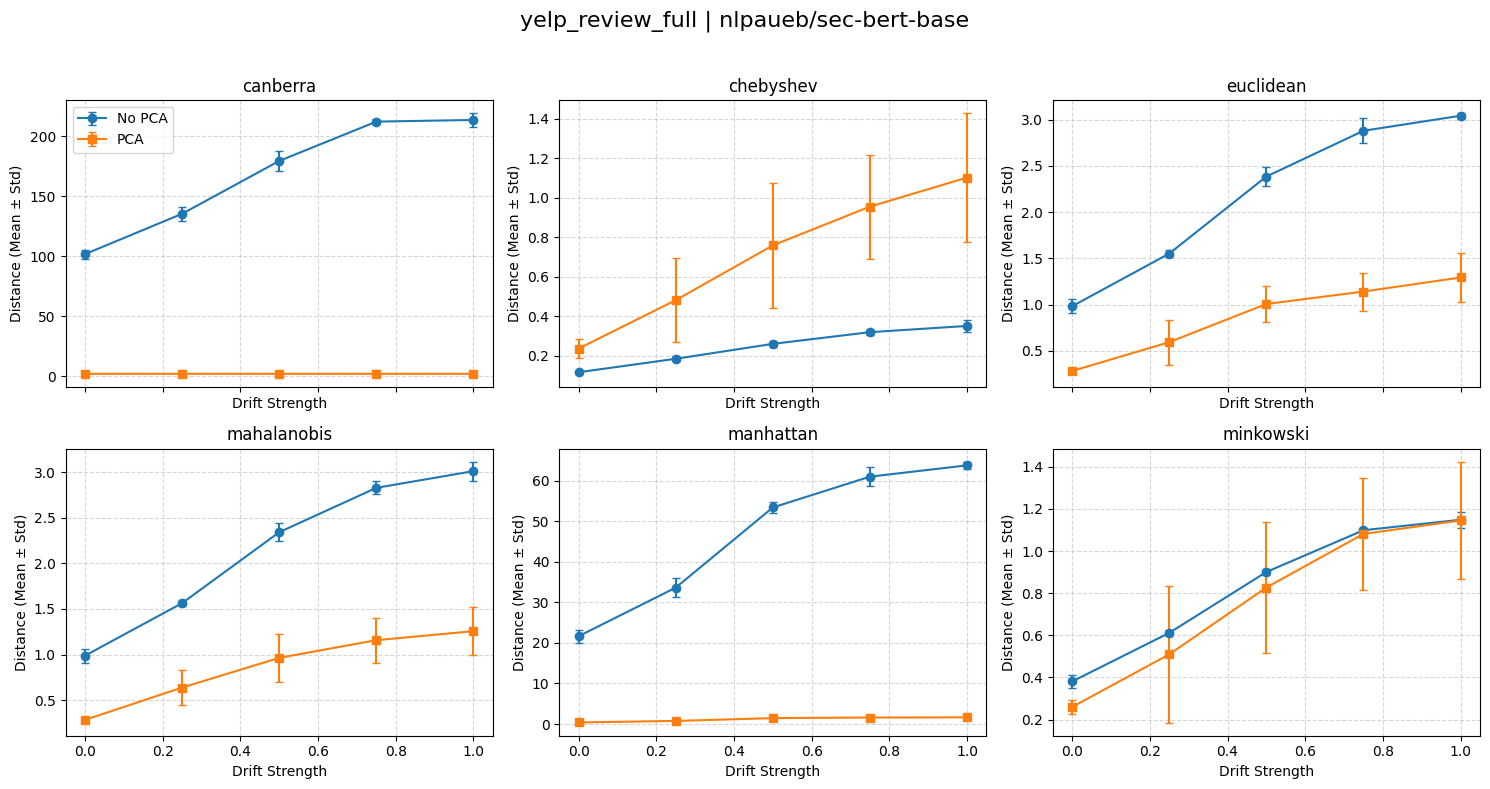

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


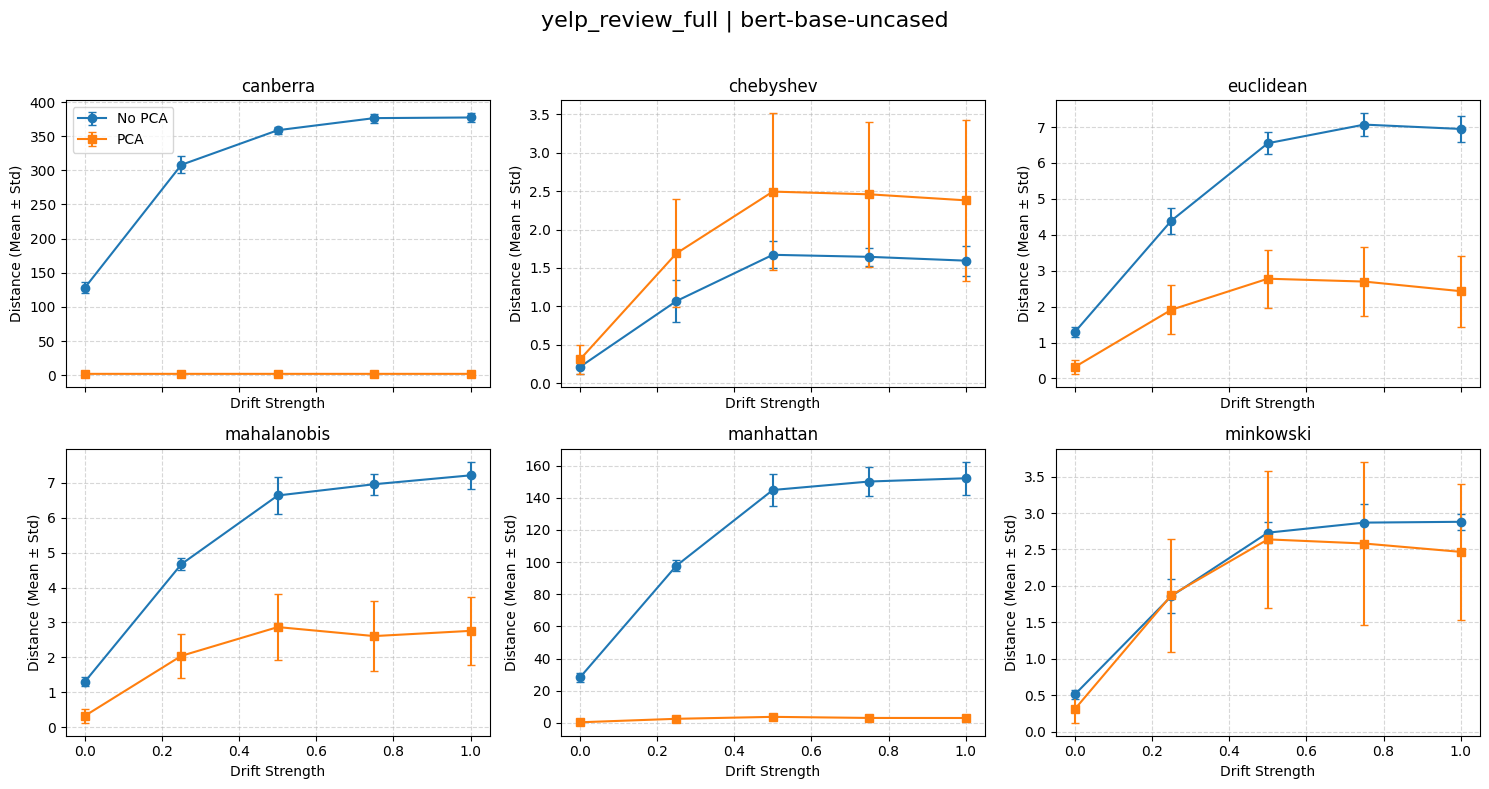

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distances_errorbars.png


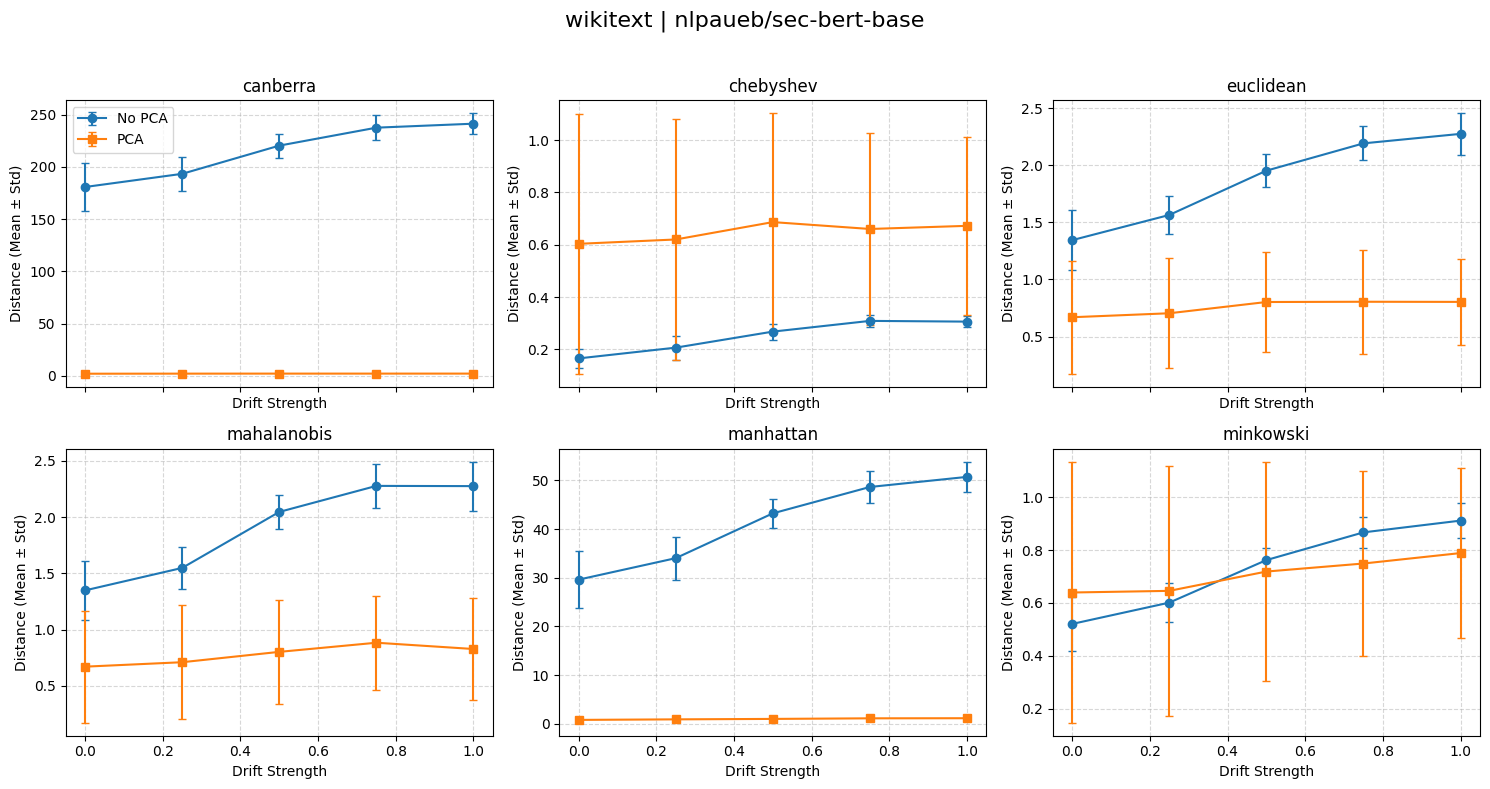

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


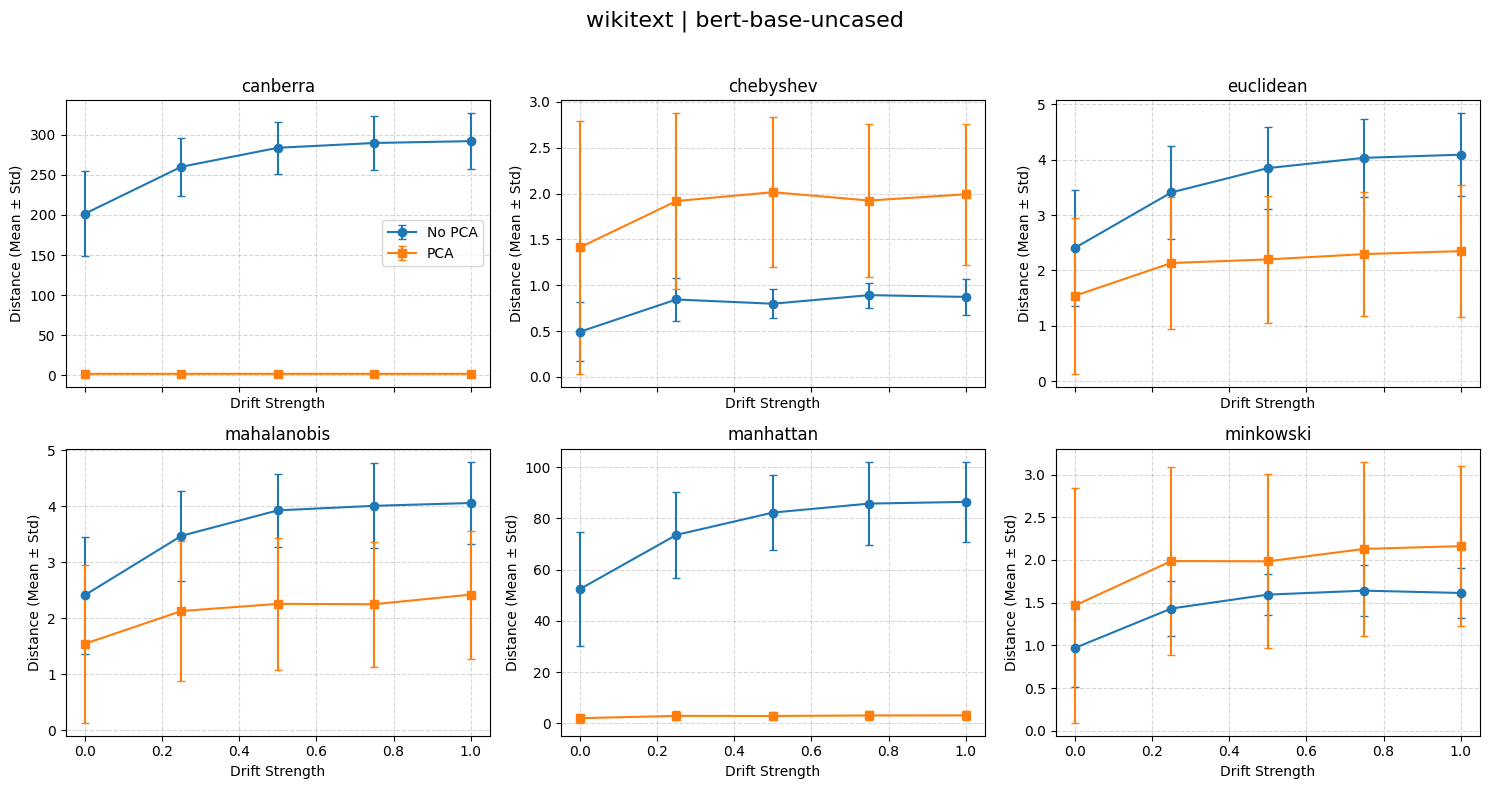

Saved figure: results_multidataset/wikitext_bert-base-uncased_distances_errorbars.png


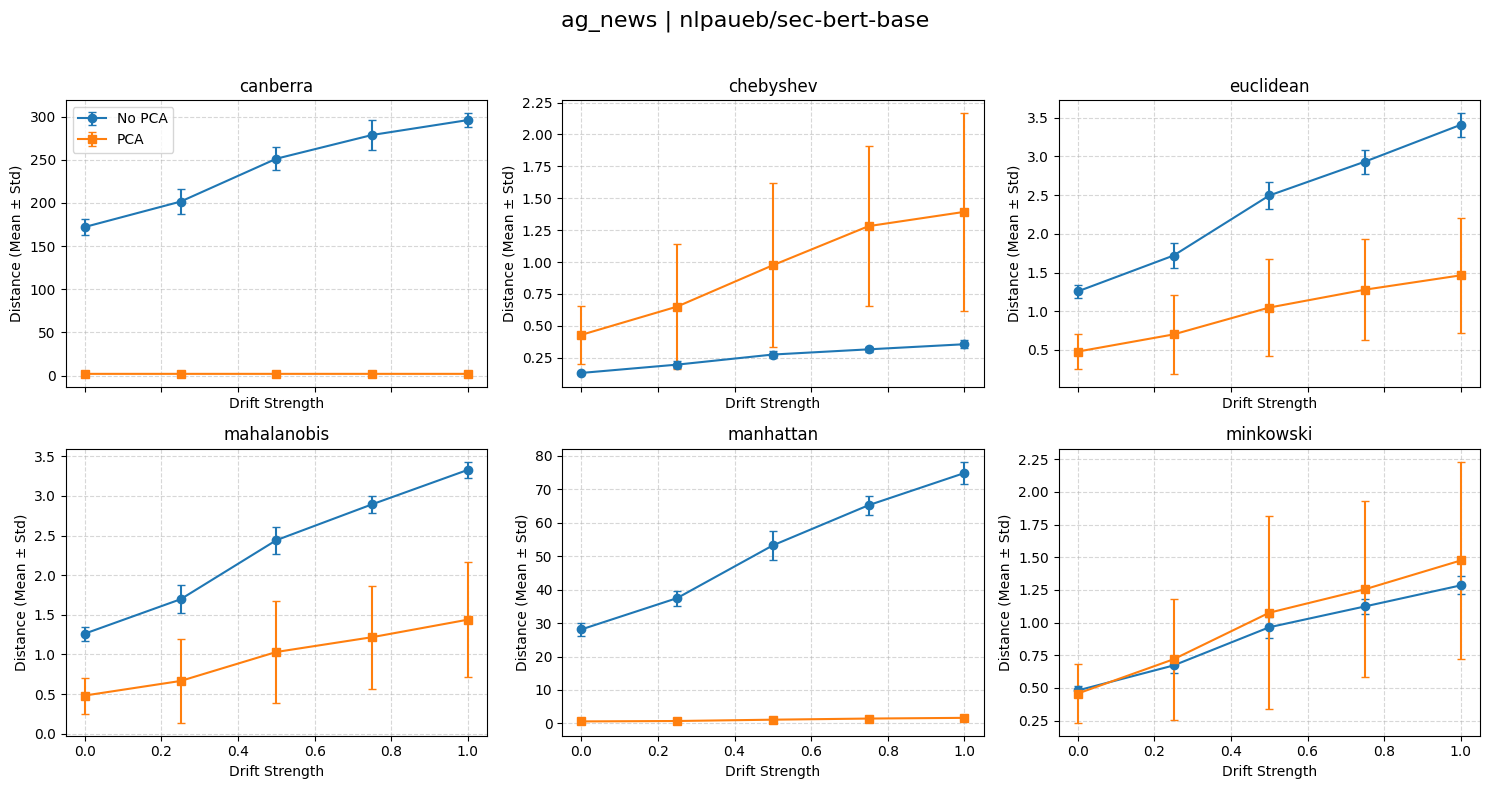

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


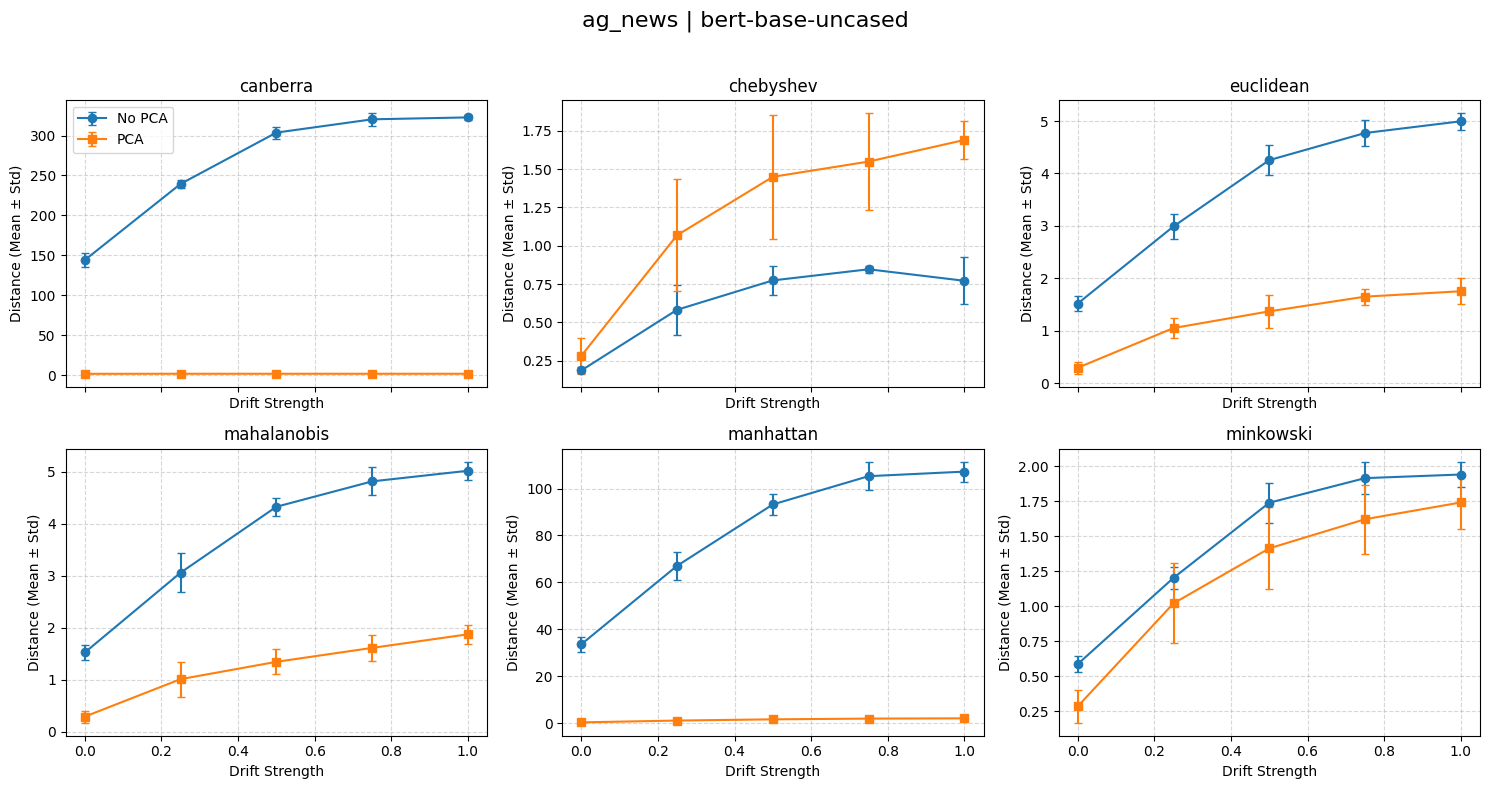

Saved figure: results_multidataset/ag_news_bert-base-uncased_distances_errorbars.png


In [3]:
###############################################################################
# 6) Plot with Error Bars
###############################################################################
def plot_distance_with_error_bars(all_results):
    """
    We aggregate across seeds: For each (dataset_name, model_name, distance_name, pca, drift_strength),
    compute the mean + std of final_distance across seeds.
    Then we plot error bars for each drift_strength for "No PCA" and "PCA" lines.
    """
    from collections import defaultdict

    # aggregated[(dataset_name, model_name, distance_name, pca, drift_strength)]
    # = list of final_distances for different seeds
    aggregator = defaultdict(list)

    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            pca_flag = r["pca"]
            final_dist = r["final_similarity"]
            seed = r["seed"]

            key = (dataset_name, model_name, dist_name, pca_flag, drift_strength)
            aggregator[key].append(final_dist)

    # Now compute mean/std
    aggregated_data = []
    for key, dist_values in aggregator.items():
        dataset_name, model_name, dist_name, pca_flag, drift_strength = key
        mean_val = np.mean(dist_values)
        std_val = np.std(dist_values)
        aggregated_data.append({
            "dataset_name": dataset_name,
            "model_name": model_name,
            "distance_name": dist_name,
            "pca": pca_flag,
            "drift_strength": drift_strength,
            "mean_val": mean_val,
            "std_val": std_val
        })

    # Now let's group by (dataset_name, model_name) for plotting
    from collections import defaultdict
    grouped = defaultdict(list)
    for row in aggregated_data:
        ds = row["dataset_name"]
        md = row["model_name"]
        grouped[(ds, md)].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        # Gather all distance names
        dist_names = sorted(set(r["distance_name"] for r in rows))

        # Create subplots
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            # Filter for this dist_name, then separate PCA vs No PCA
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            no_pca = [r for r in dist_rows if r["pca"] == False]
            pca = [r for r in dist_rows if r["pca"] == True]

            no_pca_sorted = sorted(no_pca, key=lambda x: x["drift_strength"])
            pca_sorted = sorted(pca, key=lambda x: x["drift_strength"])

            x_no_pca = [r["drift_strength"] for r in no_pca_sorted]
            y_no_pca = [r["mean_val"] for r in no_pca_sorted]
            e_no_pca = [r["std_val"] for r in no_pca_sorted]

            x_pca = [r["drift_strength"] for r in pca_sorted]
            y_pca = [r["mean_val"] for r in pca_sorted]
            e_pca = [r["std_val"] for r in pca_sorted]

            # Plot error bars
            ax.errorbar(x_no_pca, y_no_pca, yerr=e_no_pca,
                        fmt='-o', capsize=3, label="No PCA")

            ax.errorbar(x_pca, y_pca, yerr=e_pca,
                        fmt='-s', capsize=3, label="PCA")

            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance (Mean ± Std)")
            ax.grid(True, linestyle='--', alpha=0.5)
            if i == 0:
                ax.legend()

        # Hide leftover plots if any
        for j in range(i+1, n_rows*n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distance_with_error_bars(all_results)

              Dataset                  Model distance_name    pca  \
0             ag_news      bert-base-uncased      canberra  False   
1             ag_news      bert-base-uncased      canberra  False   
2             ag_news      bert-base-uncased      canberra  False   
3             ag_news      bert-base-uncased      canberra  False   
4             ag_news      bert-base-uncased      canberra  False   
..                ...                    ...           ...    ...   
355  yelp_review_full  nlpaueb/sec-bert-base     minkowski   True   
356  yelp_review_full  nlpaueb/sec-bert-base     minkowski   True   
357  yelp_review_full  nlpaueb/sec-bert-base     minkowski   True   
358  yelp_review_full  nlpaueb/sec-bert-base     minkowski   True   
359  yelp_review_full  nlpaueb/sec-bert-base     minkowski   True   

     drift_strength  mean_overhead  std_overhead  
0              0.00       0.000025      0.000004  
1              0.25       0.000025      0.000004  
2              0.5

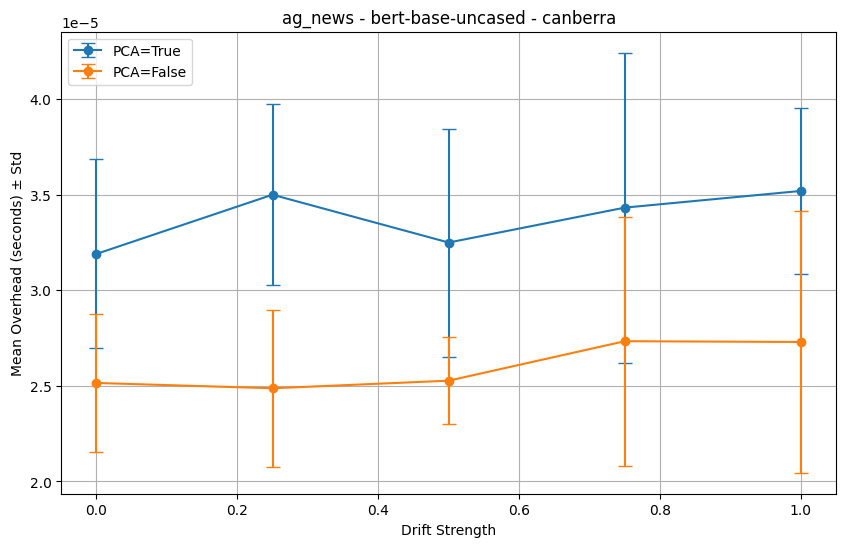

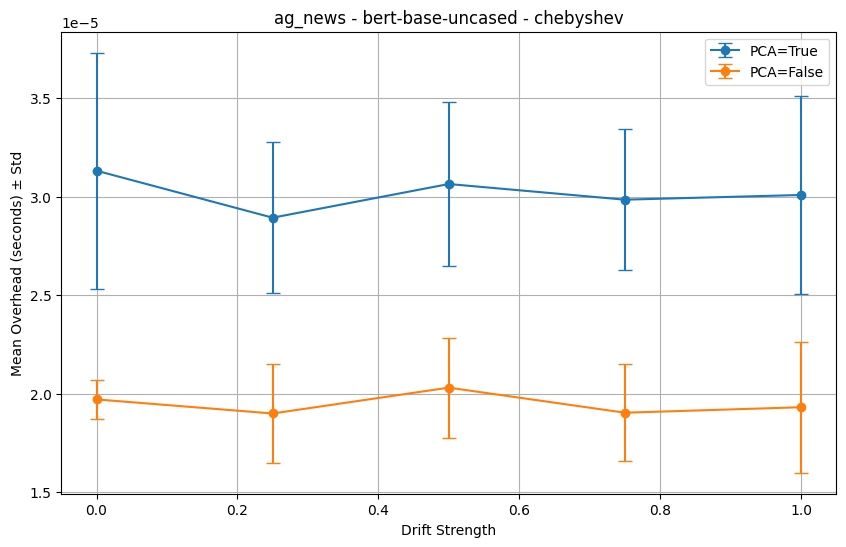

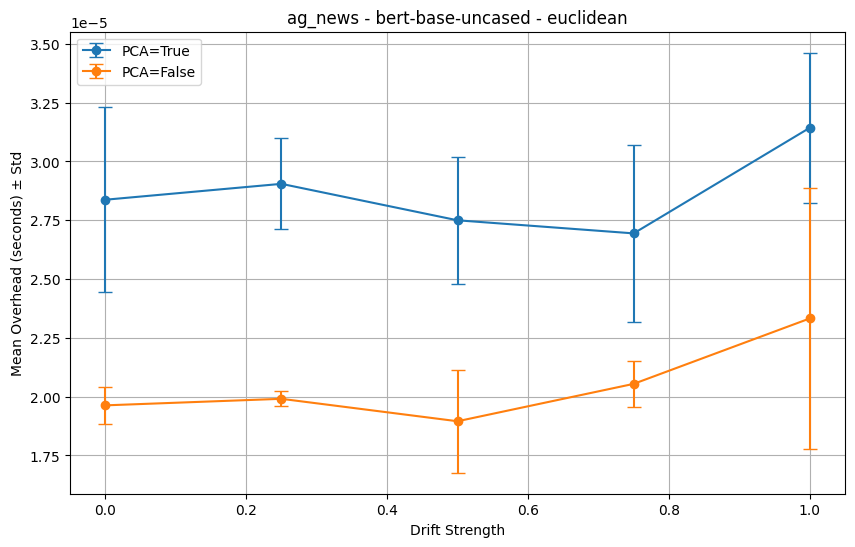

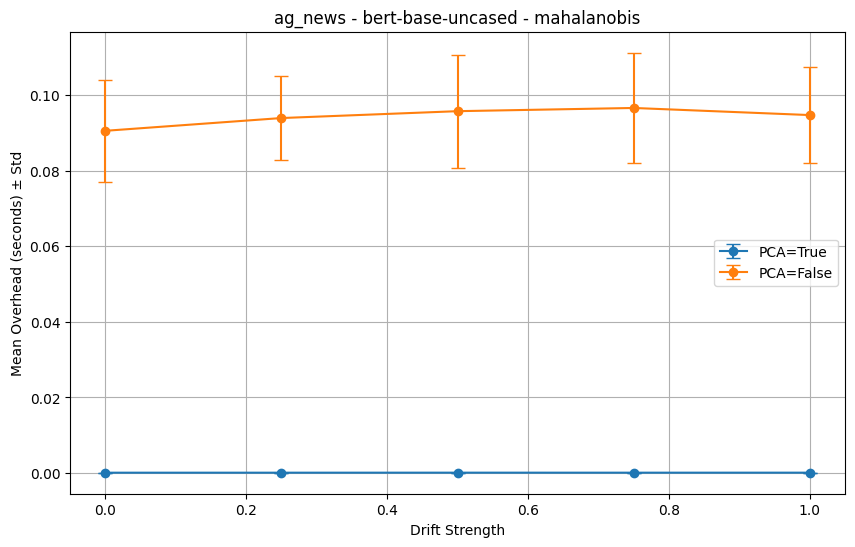

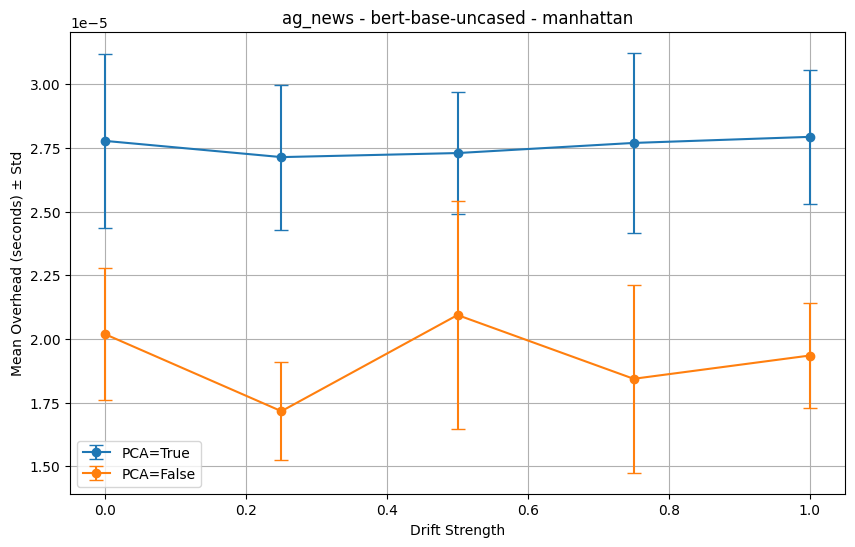

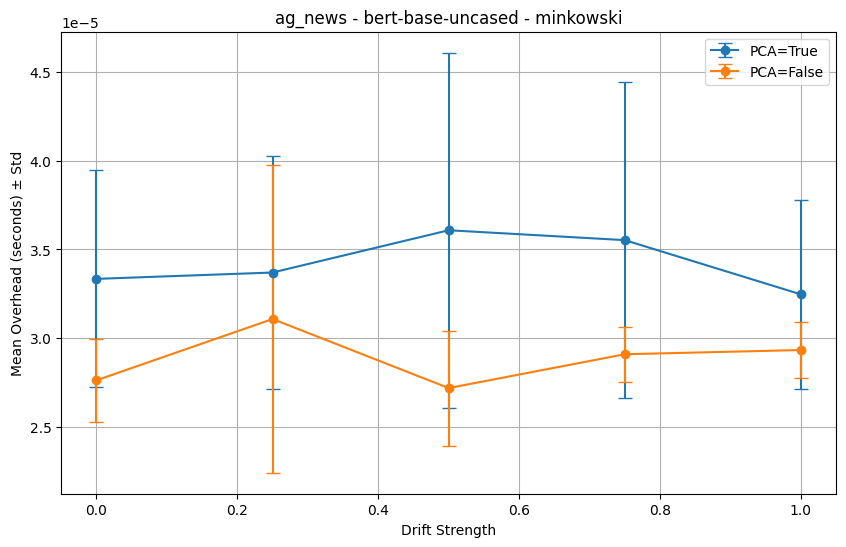

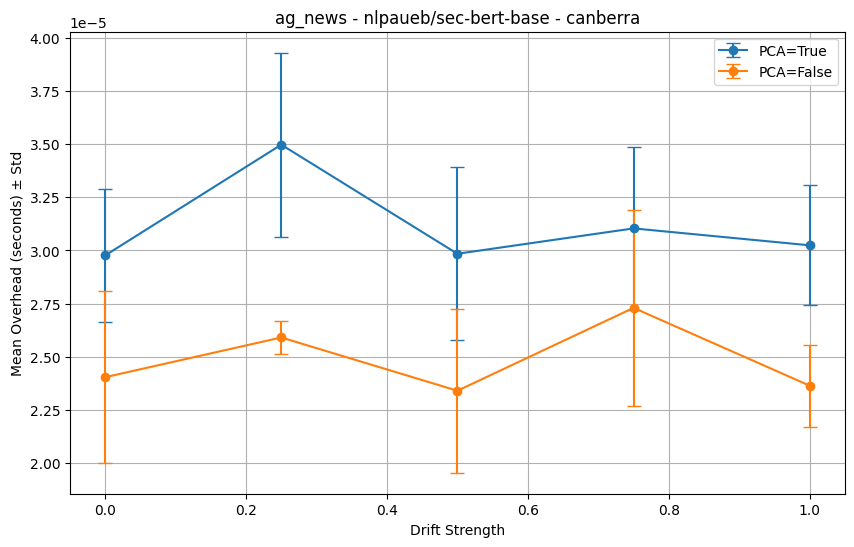

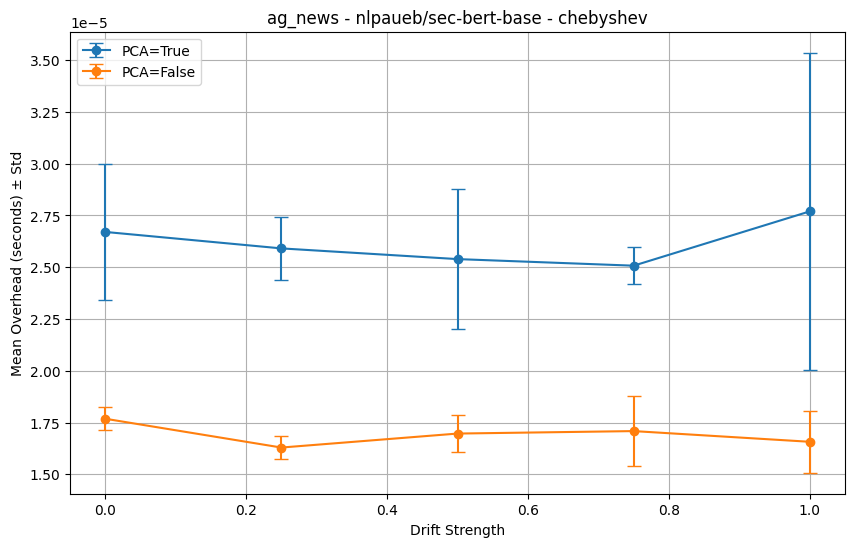

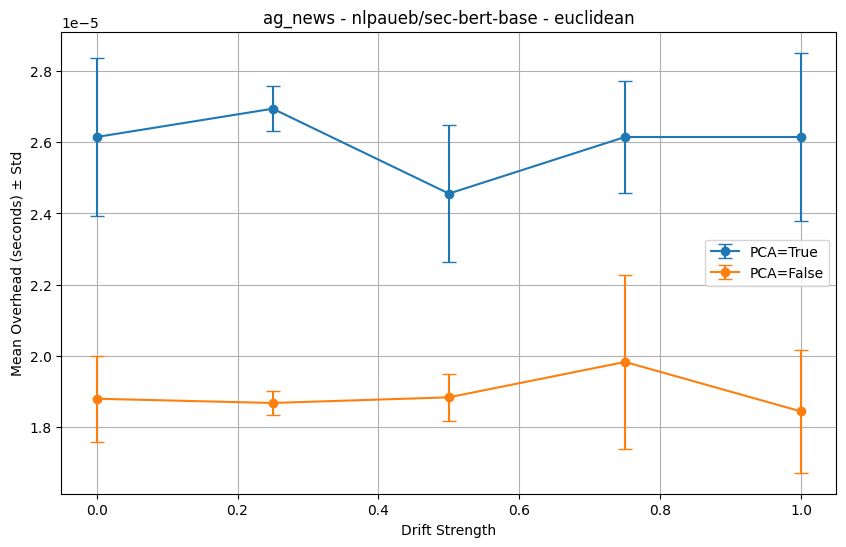

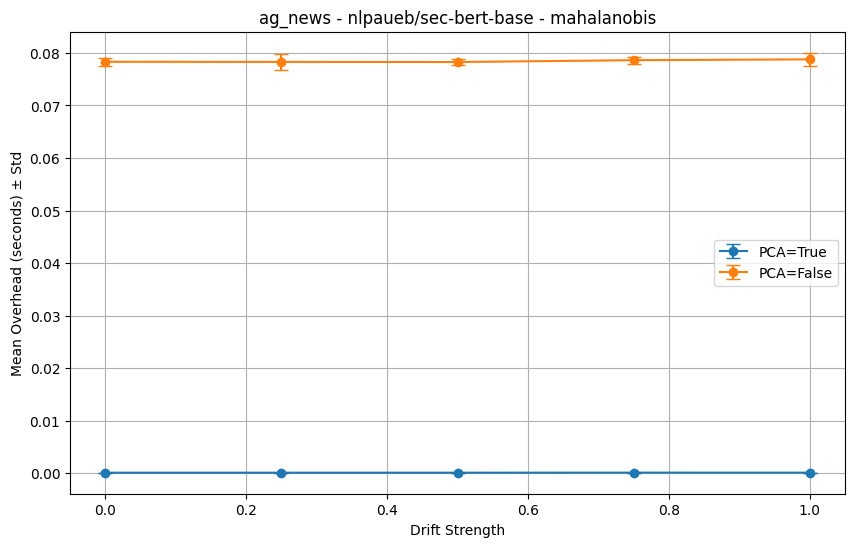

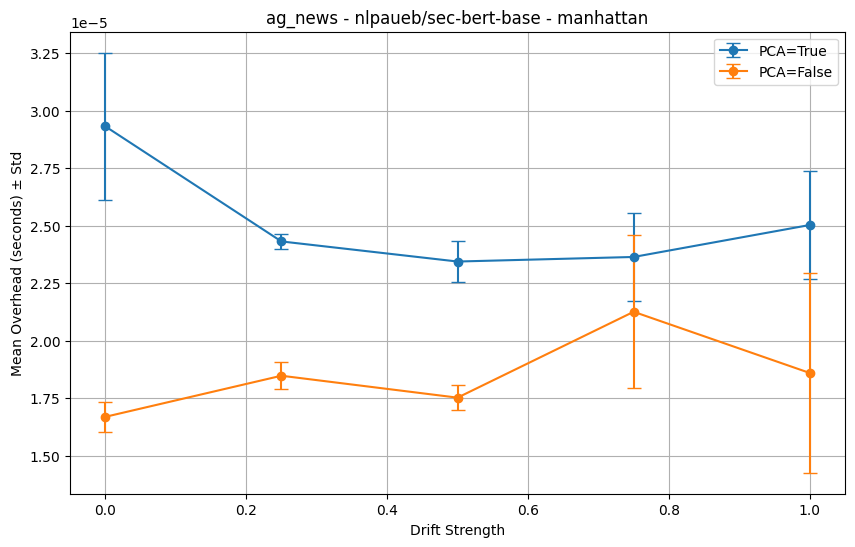

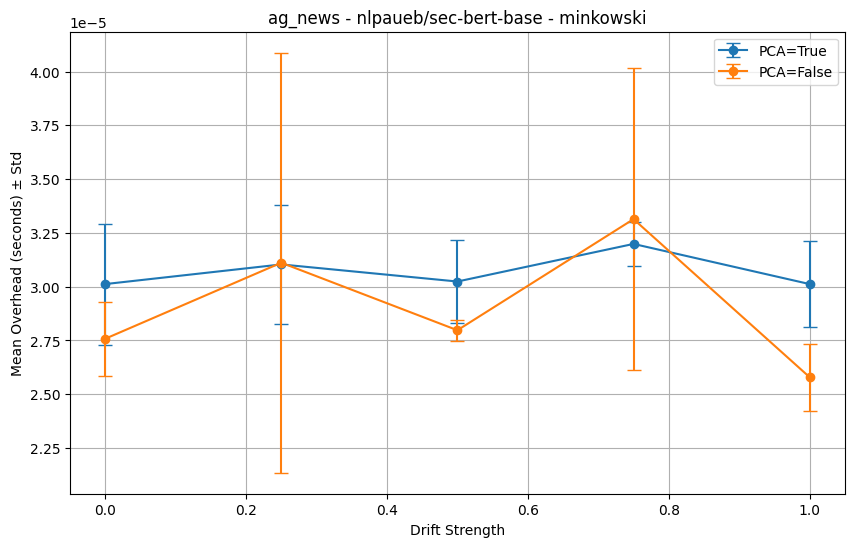

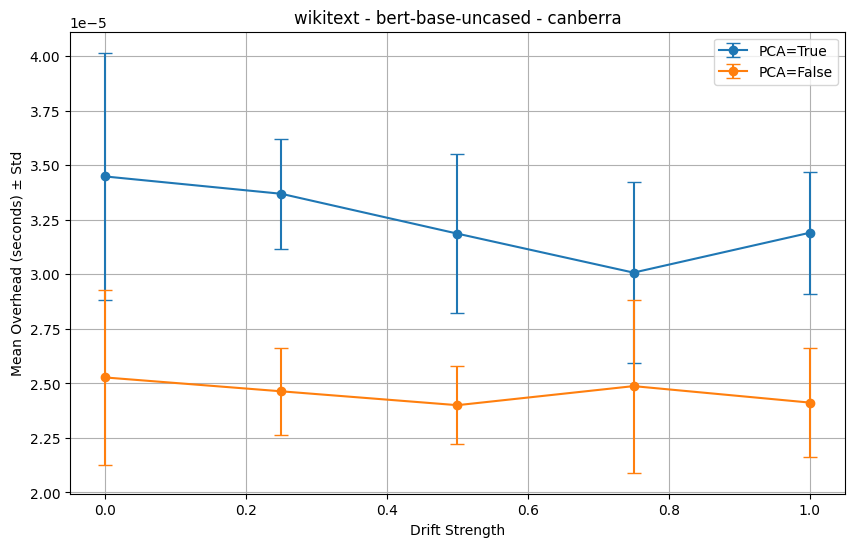

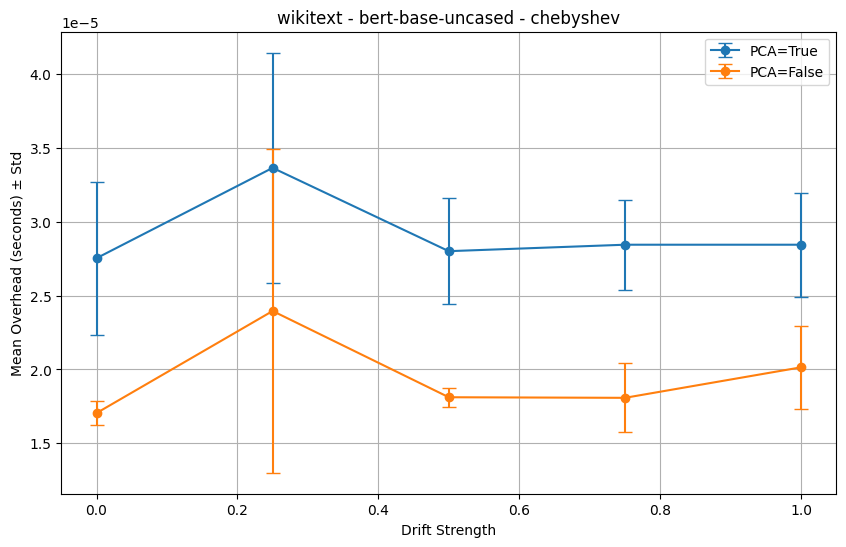

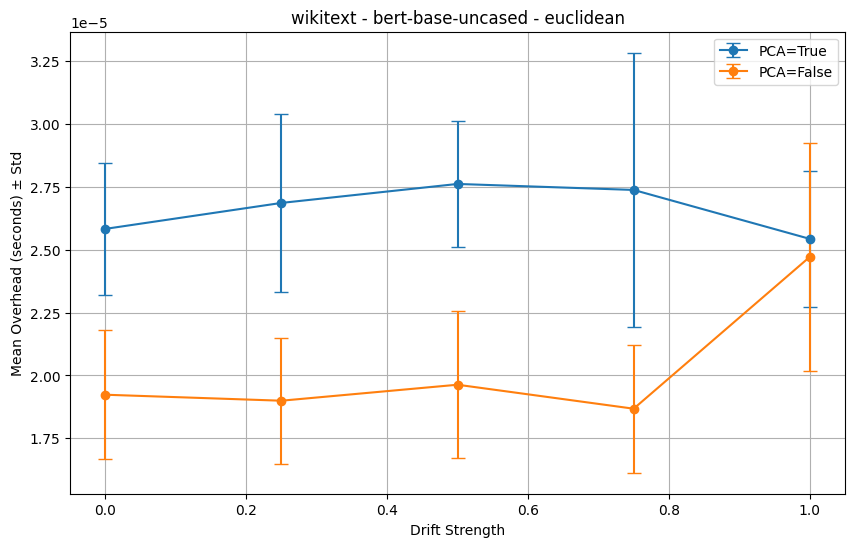

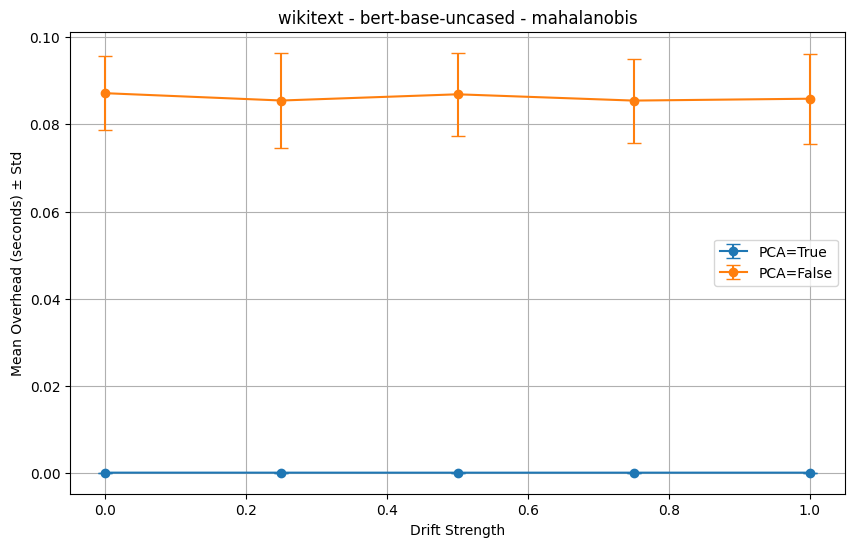

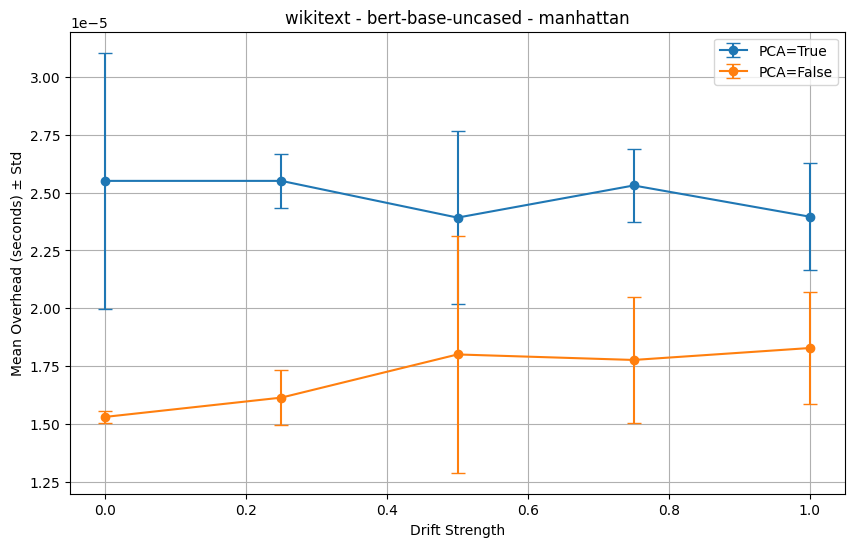

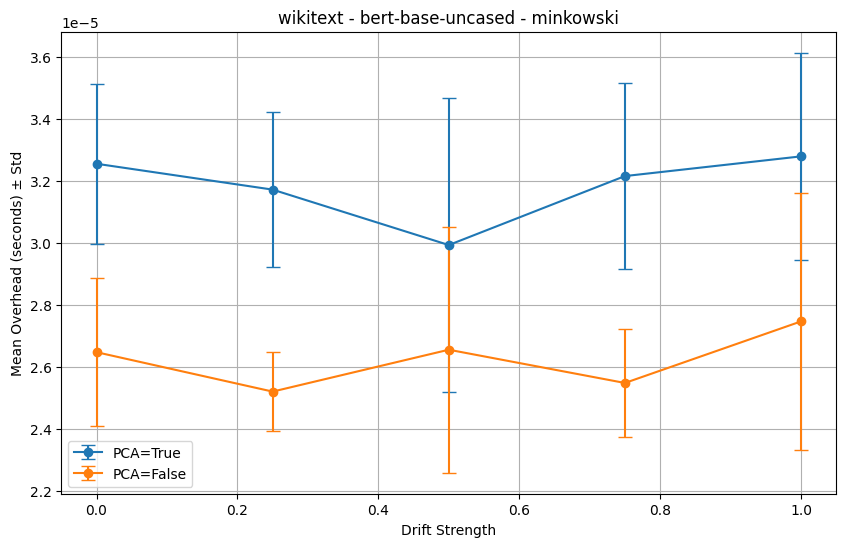

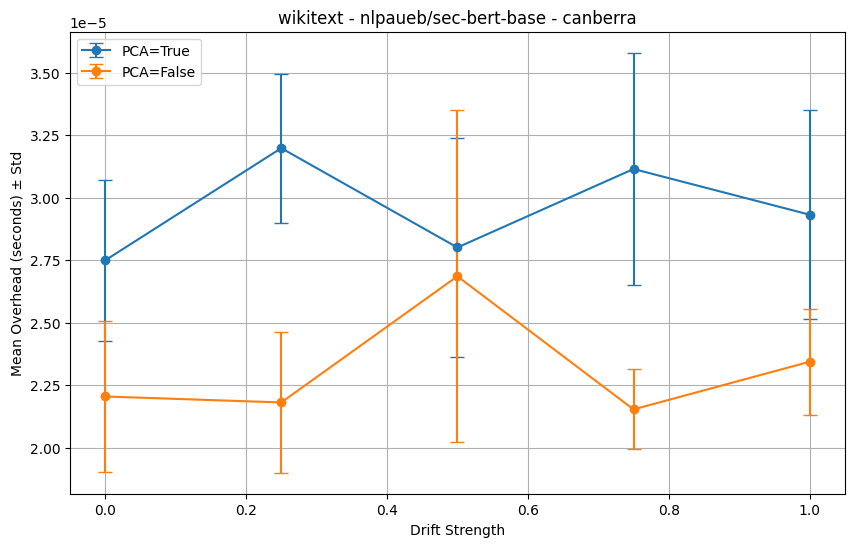

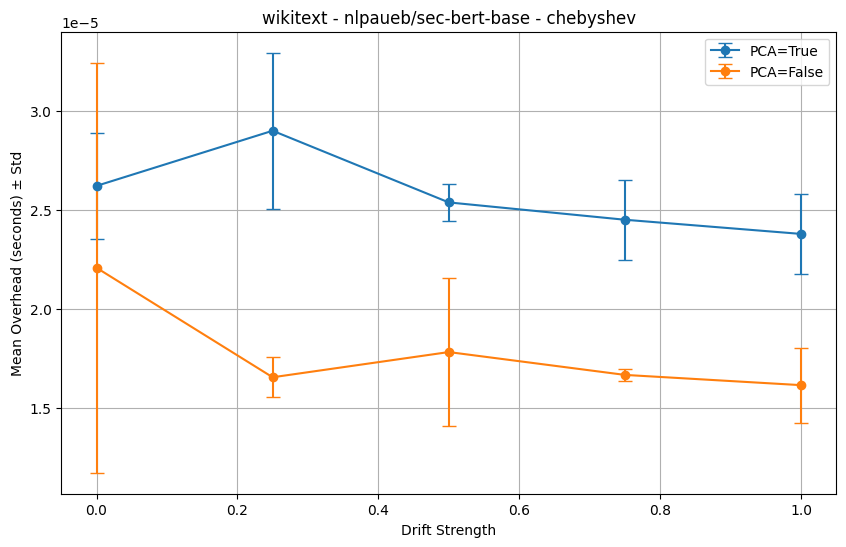

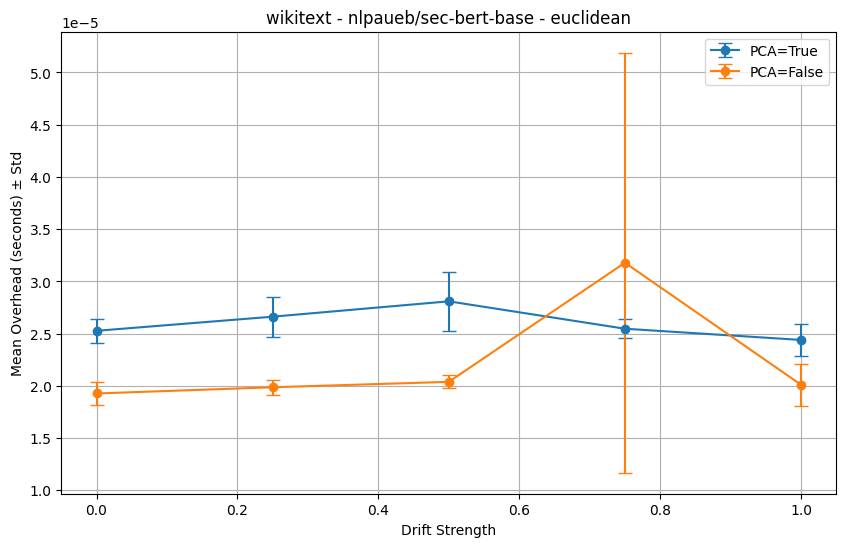

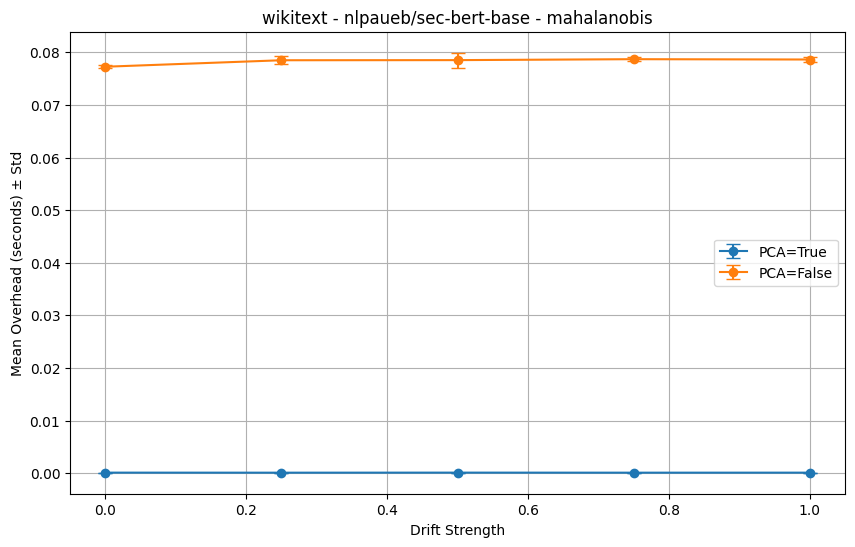

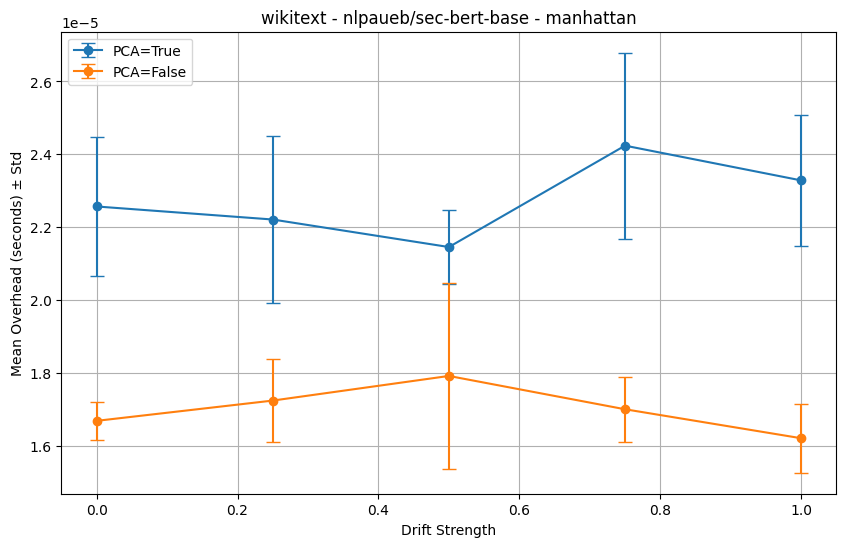

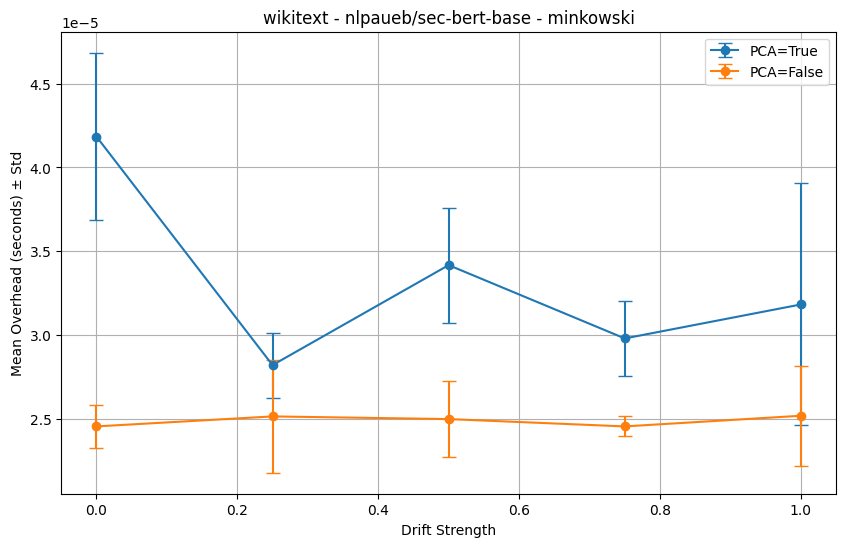

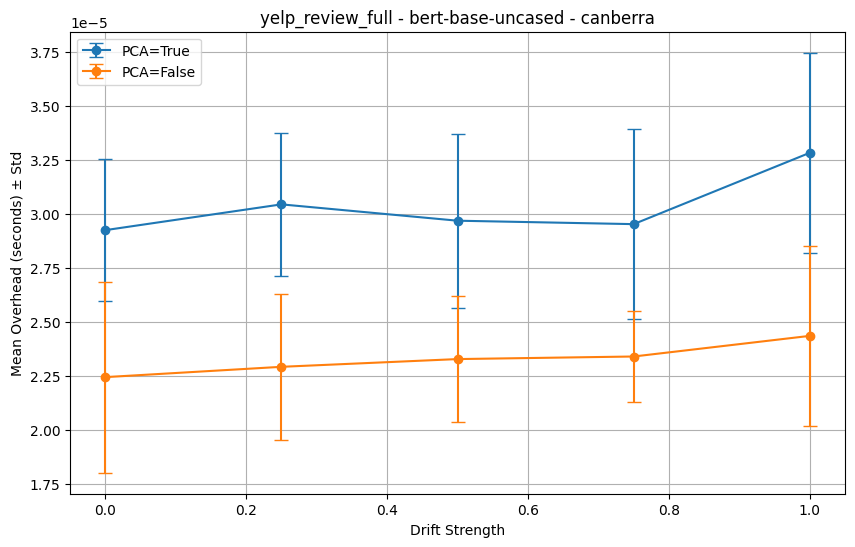

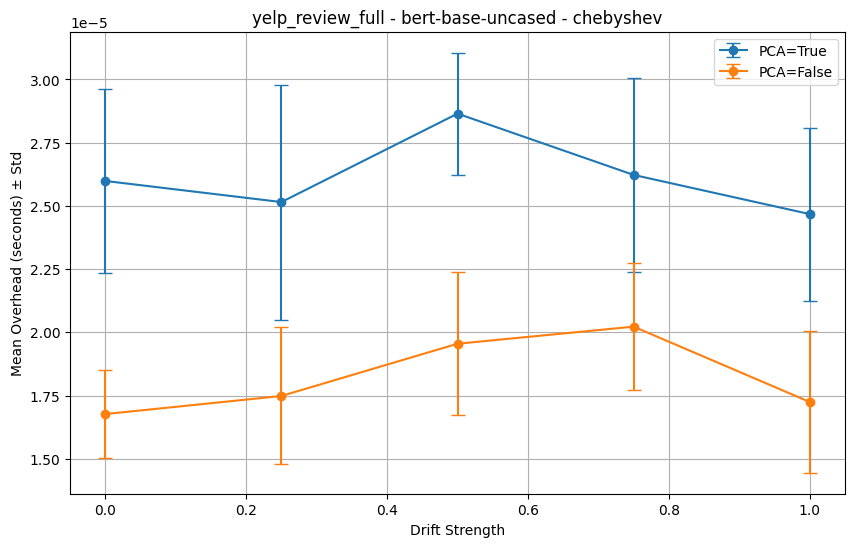

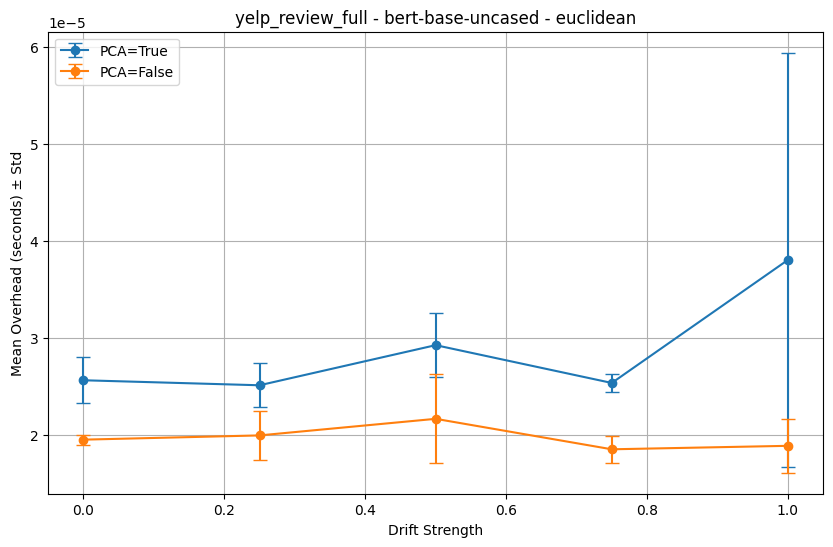

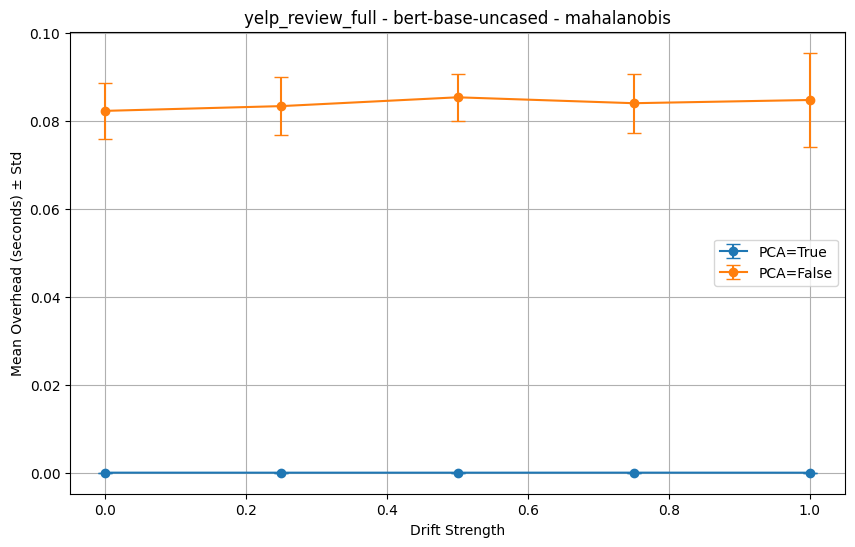

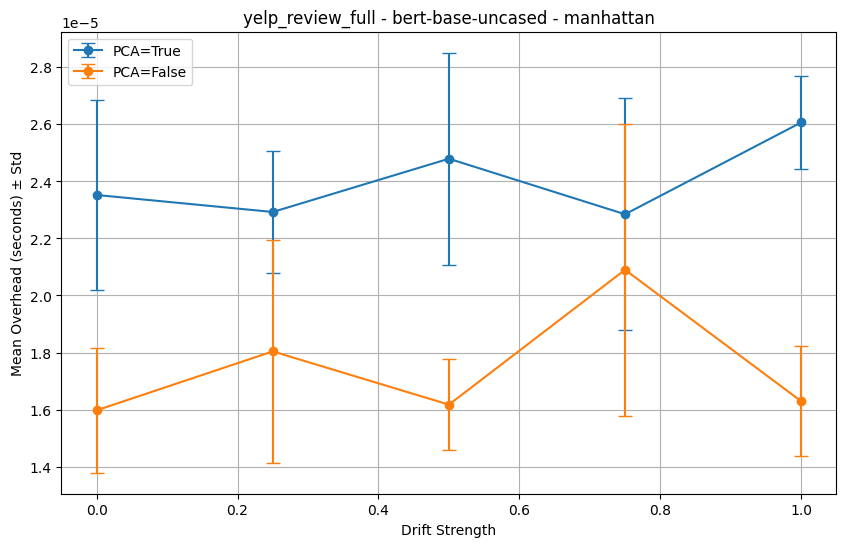

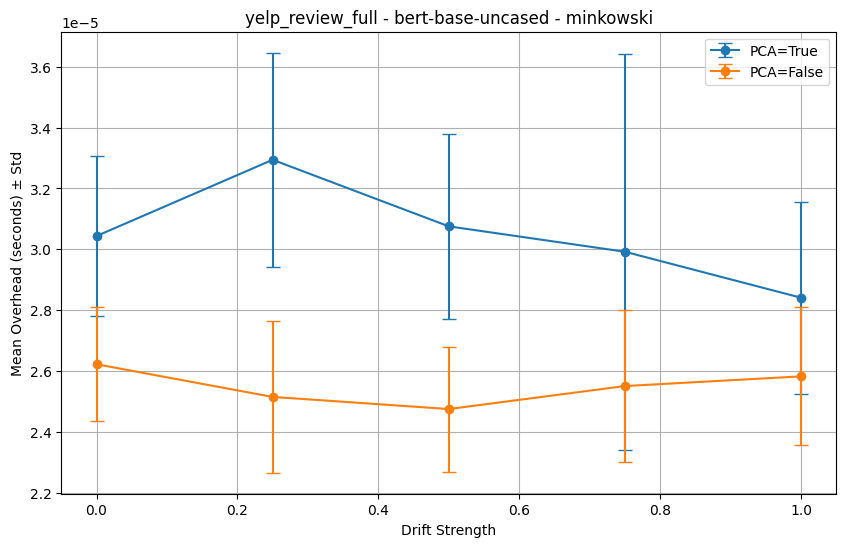

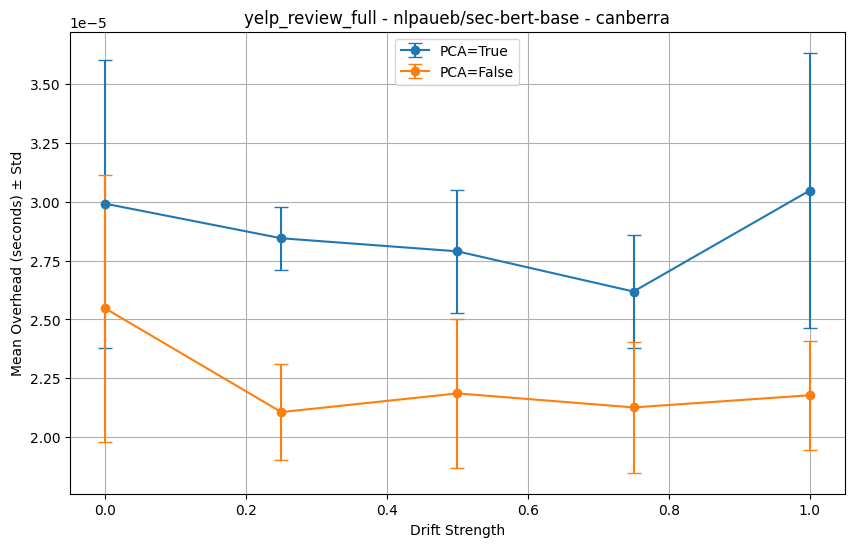

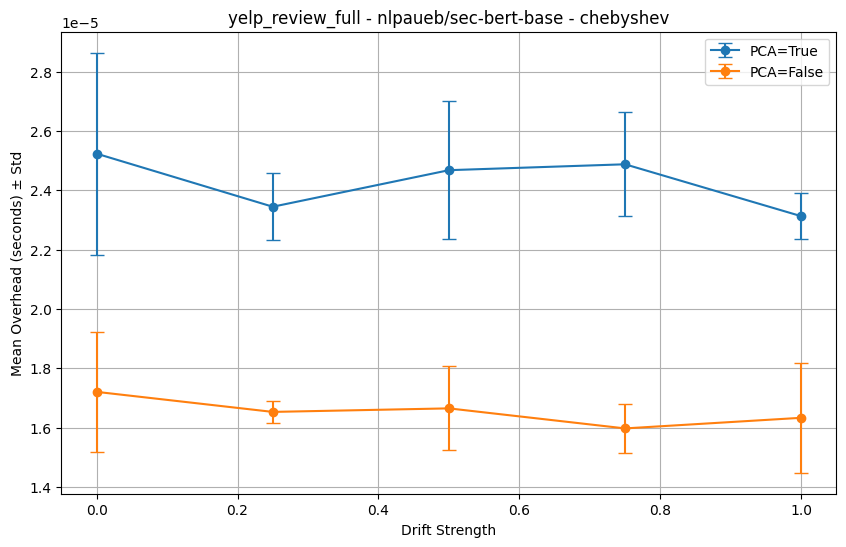

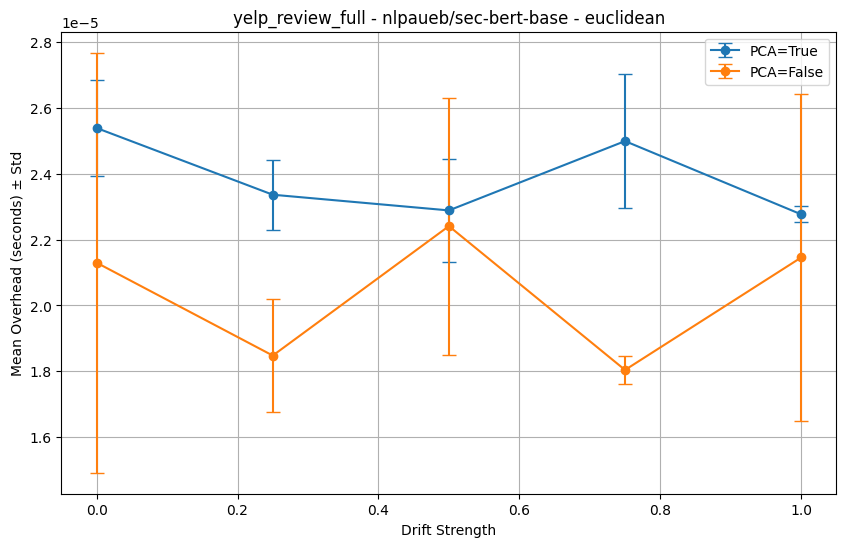

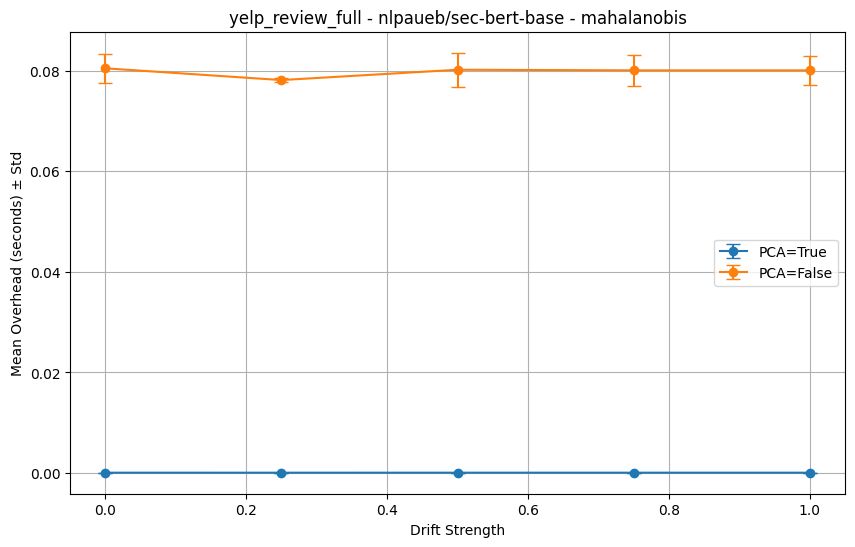

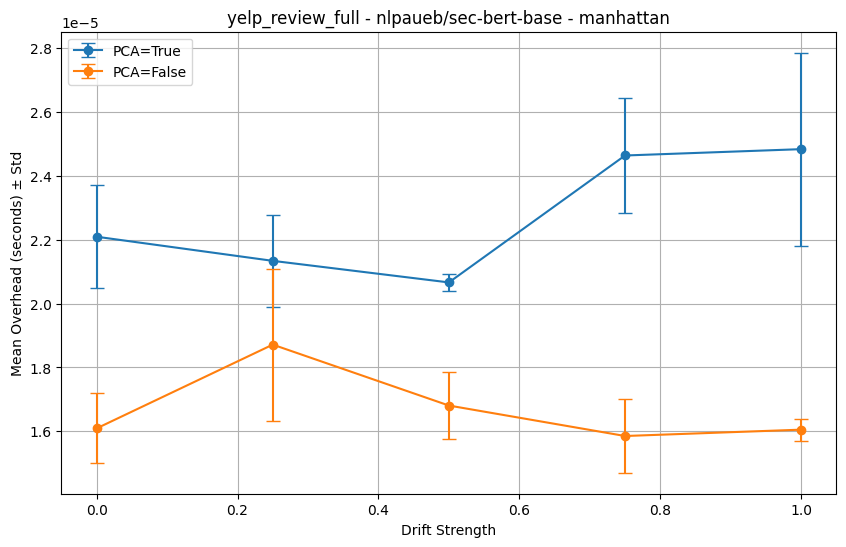

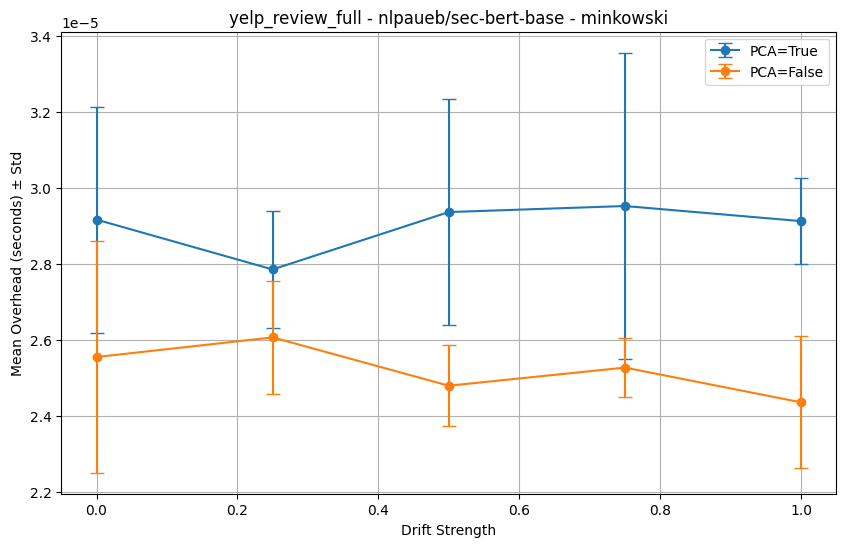

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Load the results from the CSV file
results_path = os.path.join("results_multidataset", "all_results_vector_space.csv")
df = pd.read_csv(results_path)

# Compute summary statistics for overhead
summary_overhead = df.groupby(["Dataset", "Model", "distance_name", "pca", "drift_strength"]).agg(
    mean_overhead=("avg_overhead", "mean"),
    std_overhead=("avg_overhead", "std")
).reset_index()

# Print summary statistics
print(summary_overhead)

# Visualize the overhead results
def plot_overhead(summary_overhead):
    datasets = summary_overhead["Dataset"].unique()
    models = summary_overhead["Model"].unique()
    distance_names = summary_overhead["distance_name"].unique()

    for dataset in datasets:
        for model in models:
            for distance_name in distance_names:
                subset = summary_overhead[(summary_overhead["Dataset"] == dataset) &
                                          (summary_overhead["Model"] == model) &
                                          (summary_overhead["distance_name"] == distance_name)]

                plt.figure(figsize=(10, 6))
                for pca_flag in [True, False]:
                    pca_subset = subset[subset["pca"] == pca_flag]
                    plt.errorbar(pca_subset["drift_strength"], pca_subset["mean_overhead"],
                                 yerr=pca_subset["std_overhead"],
                                 label=f'PCA={pca_flag}', capsize=5, marker='o')

                plt.title(f"{dataset} - {model} - {distance_name}")
                plt.xlabel("Drift Strength")
                plt.ylabel("Mean Overhead (seconds) ± Std")
                plt.legend()
                plt.grid(True)
                plt.show()

plot_overhead(summary_overhead)